# 1 - Carregando Bibliotecas e Dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sys

try:
    from utils import iv_woe
except ImportError:
    sys.path.append('../utils')
    from utils import iv_woe

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/AnaRaquelCafe/POSTECH_AI_SCIENTIST/refs/heads/main/Base%20de%20dados%20Tech%20Challenge/desafio_nps_fase_1.csv")
df.to_csv("../data/external/desafio_nps_fase_1.csv", index=False)

In [5]:
# df = pd.read_csv('desafio_nps_fase_1.csv')

In [6]:
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## Analisando as métricas do dataframe

Tipos das colunas e análise de nulos

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

Plot das métricas de estatística descritiva de cada coluna para ter uma ideia

In [8]:
df.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


## Analisando a variável target `NPS`

In [9]:
df['nps_score'].mean()

np.float64(4.3786)

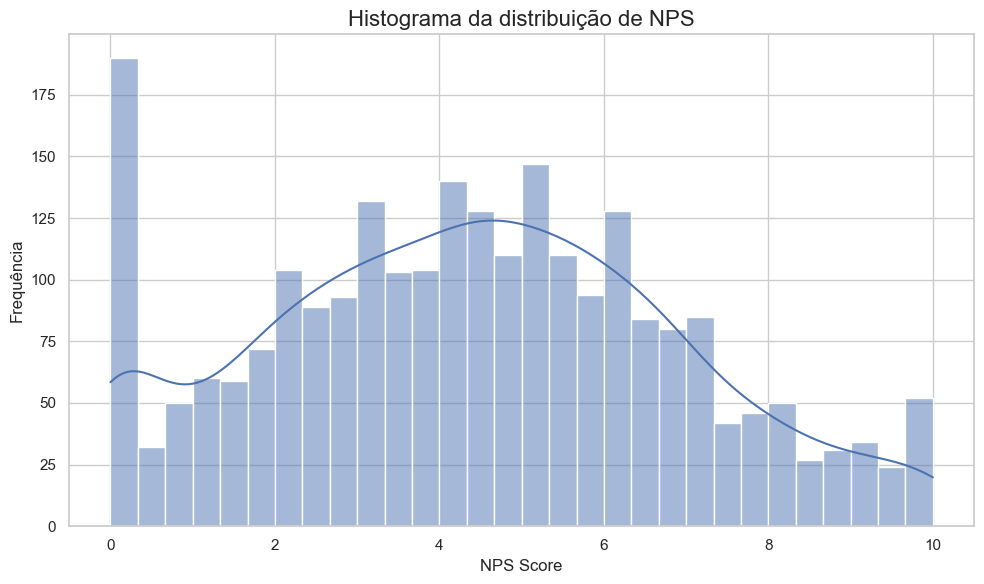

In [10]:
# Estilo visual
sns.set_theme(style="whitegrid")

# Criar o histograma
plt.figure(figsize=(10, 6))
sns.histplot(
    df.nps_score,
    bins=30,
    kde=True,
    color="#4C72B0"
)

# Títulos e rótulos
plt.title("Histograma da distribuição de NPS", fontsize=16)
plt.xlabel("NPS Score", fontsize=12)
plt.ylabel("Frequência", fontsize=12)

plt.tight_layout()
plt.show()

**Notamos muitos NPS zerados**

Analisar separadamente a base com NPS 0 -> causas da nota 0 <br>
Analisar separadamente a base com NPS 10 -> causas da nota 10


In [11]:
df_zero = df[df['nps_score'] == 0]

In [12]:
df_prom = df[df['nps_score'] >= 9]

In [13]:
df_prom.shape

(110, 19)

In [14]:
df.shape

(2500, 19)

In [15]:
df[df['delivery_delay_days']==8]

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
772,773,21,Norte,89,50773,542.58,1,3.45,5,14,8,42.85,3,1,8,0.0,0,4,0.0
954,955,45,Sudeste,15,50955,174.88,3,15.02,9,10,8,40.97,1,2,8,0.0,0,5,0.0
1597,1598,50,Norte,118,51598,316.61,4,39.48,5,4,8,36.26,2,2,1,0.0,0,4,0.0


In [16]:
df_zero.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.0,158.0,158.000000,158.000000
mean,1167.993671,44.645570,61.715190,51167.993671,417.211203,3.322785,28.307468,6.094937,8.164557,4.107595,39.106456,1.943038,2.651899,6.348101,0.0,0.0,5.759494,0.701899
std,645.949876,13.720632,33.793696,645.949876,281.148379,1.640526,25.820934,3.117217,3.855447,1.482748,12.022180,0.823567,1.427336,3.311680,0.0,0.0,1.835358,1.260951
min,8.000000,18.000000,1.000000,50008.000000,14.580000,1.000000,0.100000,1.000000,2.000000,1.000000,6.130000,1.000000,0.000000,0.000000,0.0,0.0,2.000000,0.000000
25%,611.750000,35.000000,34.250000,50611.750000,218.547500,2.000000,8.780000,3.000000,5.000000,3.000000,30.180000,1.000000,1.250000,4.000000,0.0,0.0,4.000000,0.000000
50%,1159.000000,45.500000,61.500000,51159.000000,368.575000,3.000000,20.920000,6.000000,8.000000,4.000000,40.285000,2.000000,3.000000,6.500000,0.0,0.0,6.000000,0.000000
75%,1737.000000,56.750000,89.750000,51737.000000,526.862500,5.000000,41.777500,9.000000,12.000000,5.000000,47.222500,3.000000,4.000000,9.000000,0.0,0.0,7.000000,0.900000
max,2454.000000,69.000000,118.000000,52454.000000,1842.300000,6.000000,129.590000,11.000000,14.000000,8.000000,66.870000,3.000000,7.000000,11.000000,0.0,0.0,10.000000,5.200000


In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def analise_decil(df, col, n=10):
    # Criar decis
    df = df.copy()
    df["decil"] = pd.qcut(df[col], n, labels=False, duplicates="drop") + 1


    limites = (
        df.groupby("decil")[col]
          .agg(min_val="min", max_val="max")
    )

    print(limites)

    # Agregar dados
    df_plot = (
        df.groupby("decil", as_index=False)
          .agg(nps_medio=("nps_score", "mean"))
    )

    # Estilo visual
    sns.set_theme(style="whitegrid", palette="viridis")

    # Plot
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=df_plot,
        x="decil",
        y="nps_medio",
        marker="o",
        linewidth=2
    )

    # Ajustes visuais
    plt.title("NPS Médio por Décil", fontsize=16, weight="bold")
    plt.xlabel("Décil", fontsize=12)
    plt.ylabel("NPS Médio", fontsize=12)
    plt.xticks(range(1, df_plot["decil"].max() + 1))

    plt.tight_layout()
    plt.show()

    df.drop(columns=["decil"], inplace=True)

       min_val  max_val
decil                  
1            0        1
2            2        2
3            3        3
4            4        4
5            5        8


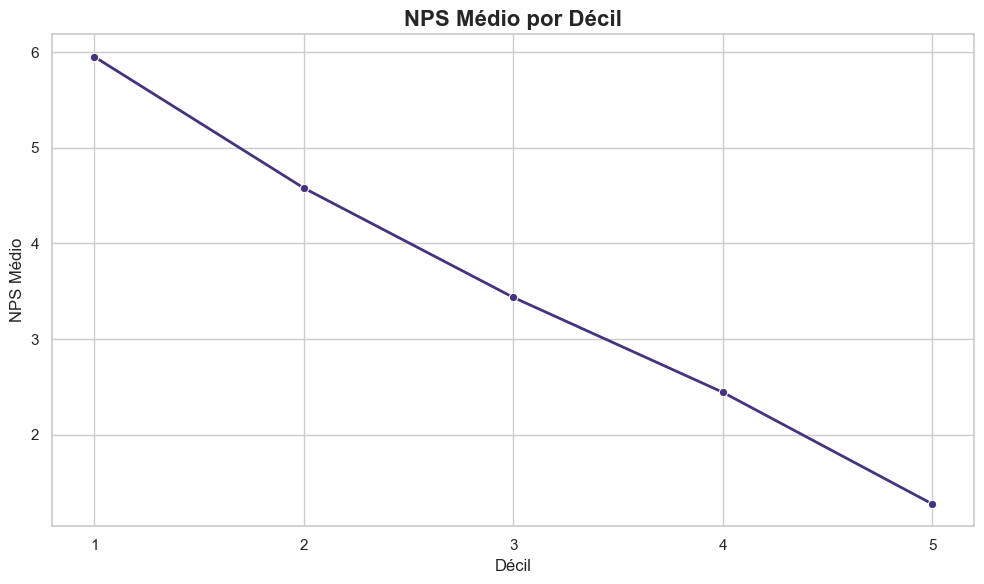

In [29]:
analise_decil(df, 'delivery_delay_days')

       min_val  max_val
decil                  
1         7.76   126.52
2       126.73   191.56
3       191.86   249.43
4       250.52   312.04
5       312.27   375.46
6       375.57   446.05
7       446.12   525.26
8       525.67   639.58
9       639.78   825.63
10      825.72  1983.81


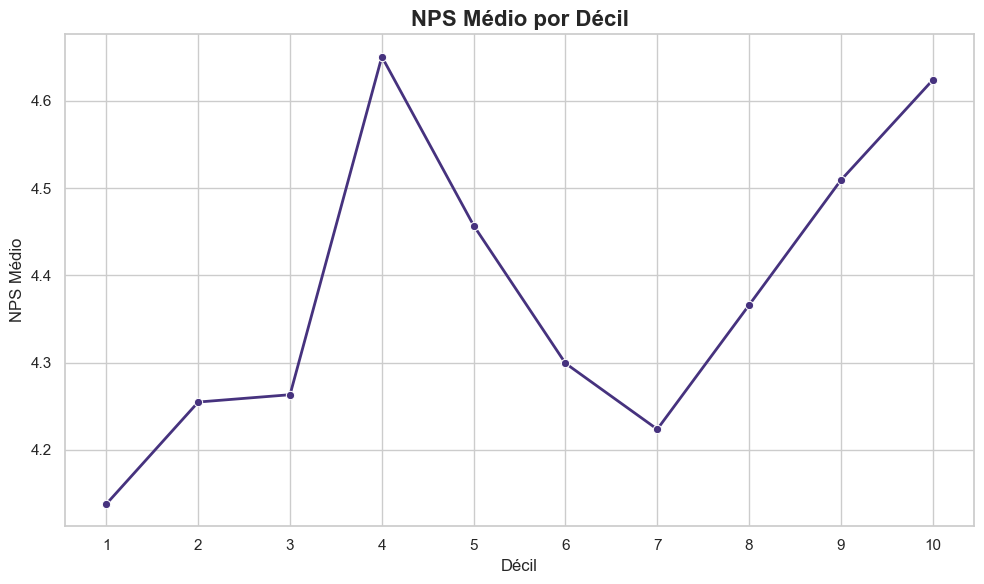

In [30]:
analise_decil(df, 'order_value', n=10)

<Axes: xlabel='delivery_delay_days', ylabel='nps_score'>

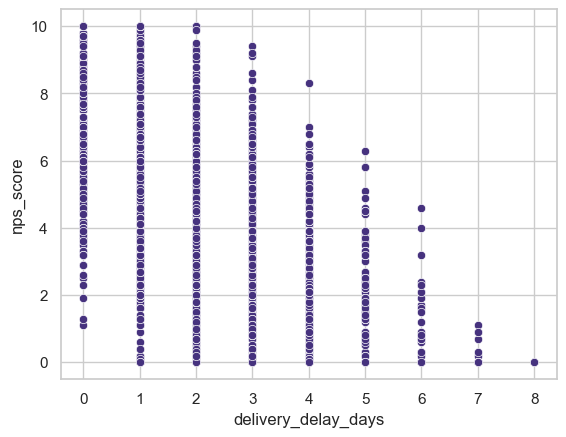

In [31]:
sns.scatterplot(df, x='delivery_delay_days', y='nps_score')

<Axes: xlabel='customer_region', ylabel='delivery_time_days'>

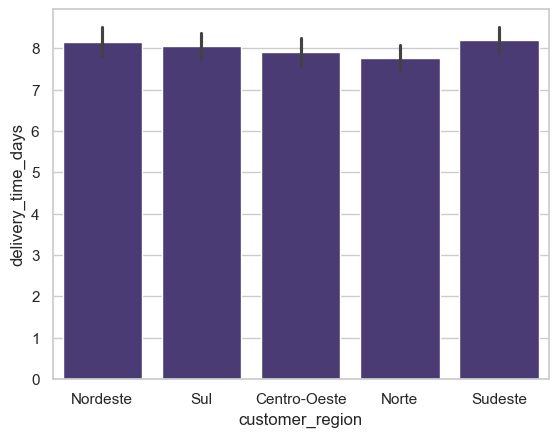

In [32]:
sns.barplot(df, x='customer_region', y='delivery_time_days')

<Axes: xlabel='decil'>

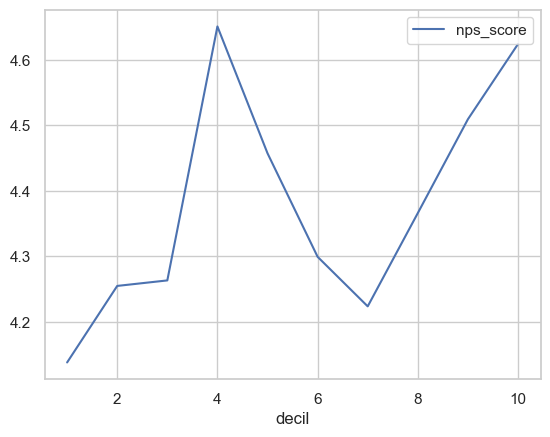

In [18]:
labels = [i for i in range(1, 11)]

df["decil"] = pd.qcut(df["order_value"], 10, labels=labels)
sns.lineplot(df.groupby('decil').agg({'nps_score':'mean'}))

# Vários métodos de transformar a coluna de região em numérica
- OneHotEncoder
- MeanInput
- etc

In [19]:
def print_correlacao(df):
  # 2) Selecionar apenas colunas numéricas (em um caso real: df.select_dtypes)
  num_df = df.select_dtypes(include=[np.number])

  # 3) Calcular a matriz de correlação (Pearson por padrão)
  corr = num_df.corr(method='pearson')

  # 4) Plotar como heatmap com cores por intensidade
  plt.figure(figsize=(12, 12))
  # Colormap divergente enfatiza sinais positivos/negativos
  cmap = sns.diverging_palette(240, 10, as_cmap=True)  # azul->vermelho

  # Máscara para mostrar apenas triângulo inferior (opcional)
  mask = np.triu(np.ones_like(corr, dtype=bool))

  ax = sns.heatmap(
      corr,
      mask=mask,
      cmap=cmap,
      vmin=-1, vmax=1,  # intensidade fixa em [-1, 1]
      center=0,
      annot=True, fmt=".2f",  # anotações opcionais
      linewidths=0.5,
      cbar_kws={"label": "Correlação de Pearson"}
  )
  ax.set_title("Mapa de calor das correlações (intensidade de cor)")
  plt.tight_layout()

  # Retornar algumas informações úteis
  corr_summary = corr.round(2).to_dict()
  {'arquivo': 'correlation_heatmap_exemplo.png', 'dimensoes': corr.shape, 'amostra_corr': list(corr_summary.items())[:3]}

  plt.show()


In [20]:
df.isnull().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
decil                        0
dtype: int64

In [21]:
df.dtypes

customer_id                     int64
customer_age                    int64
customer_region                   str
customer_tenure_months          int64
order_id                        int64
order_value                   float64
items_quantity                  int64
discount_value                float64
payment_installments            int64
delivery_time_days              int64
delivery_delay_days             int64
freight_value                 float64
delivery_attempts               int64
customer_service_contacts       int64
resolution_time_days            int64
nps_score                     float64
repeat_purchase_30d             int64
complaints_count                int64
csat_internal_score           float64
decil                        category
dtype: object

### Classificação dos Clientes:
- Promotores (9-10): Clientes fiéis e entusiastas que promovem a marca.
- Passivos/Neutros (7-8): Satisfeitos, mas não leais, vulneráveis à concorrência.
- Detratores (0-6): Clientes insatisfeitos que podem prejudicar a reputação.

In [22]:
index_prom = df['nps_score']>=9
index_neut = ((df['nps_score']<9) & (df['nps_score']>=7))
index_detr = df['nps_score']<7

In [23]:
# df.loc[index_prom, 'classificacao'] = 'Promotores'
# df.loc[index_neut, 'classificacao'] = 'Neutros'
# df.loc[index_detr, 'classificacao'] = 'Detratores'

df.loc[index_prom, 'classificacao'] = 0
df.loc[index_neut, 'classificacao'] = 0
df.loc[index_detr, 'classificacao'] = 1

In [24]:
df.dtypes

customer_id                     int64
customer_age                    int64
customer_region                   str
customer_tenure_months          int64
order_id                        int64
order_value                   float64
items_quantity                  int64
discount_value                float64
payment_installments            int64
delivery_time_days              int64
delivery_delay_days             int64
freight_value                 float64
delivery_attempts               int64
customer_service_contacts       int64
resolution_time_days            int64
nps_score                     float64
repeat_purchase_30d             int64
complaints_count                int64
csat_internal_score           float64
decil                        category
classificacao                 float64
dtype: object

In [25]:
df['classificacao'] = df['classificacao'].astype(int)
newDF,woeDF = iv_woe(df.drop(columns=['customer_region']), target='classificacao')

Information value of customer_id is 0.023822
Information value of customer_age is 0.087312
Information value of customer_tenure_months is 0.019884
Information value of order_id is 0.023822
Information value of order_value is 0.025407
Information value of items_quantity is 0.006398
Information value of discount_value is 0.029839
Information value of payment_installments is 0.011588
Information value of delivery_time_days is 0.031325
Information value of delivery_delay_days is 1.568505
Information value of freight_value is 0.018506
Information value of delivery_attempts is 0.02115
Information value of customer_service_contacts is 0.43111
Information value of resolution_time_days is 0.167429
Information value of nps_score is 9.858712
Information value of repeat_purchase_30d is 4.780957
Information value of complaints_count is 1.295487
Information value of csat_internal_score is 1.348664
Information value of decil is 0.025407


### Features Importantes
- repeat_purchase -> data leakage
- delivery_delay_days
- csat_internal_score
- complaints_count


### Features com baixo ou médio poder pre
- customer_service_contacts
- resolution_time_days
- customer_age
- order_value
- discount_value
- delivery_time_days
- delivery_attempts

In [26]:
df.nps_score.mean()

np.float64(4.3786)

In [27]:
df_detr = df[index_detr]

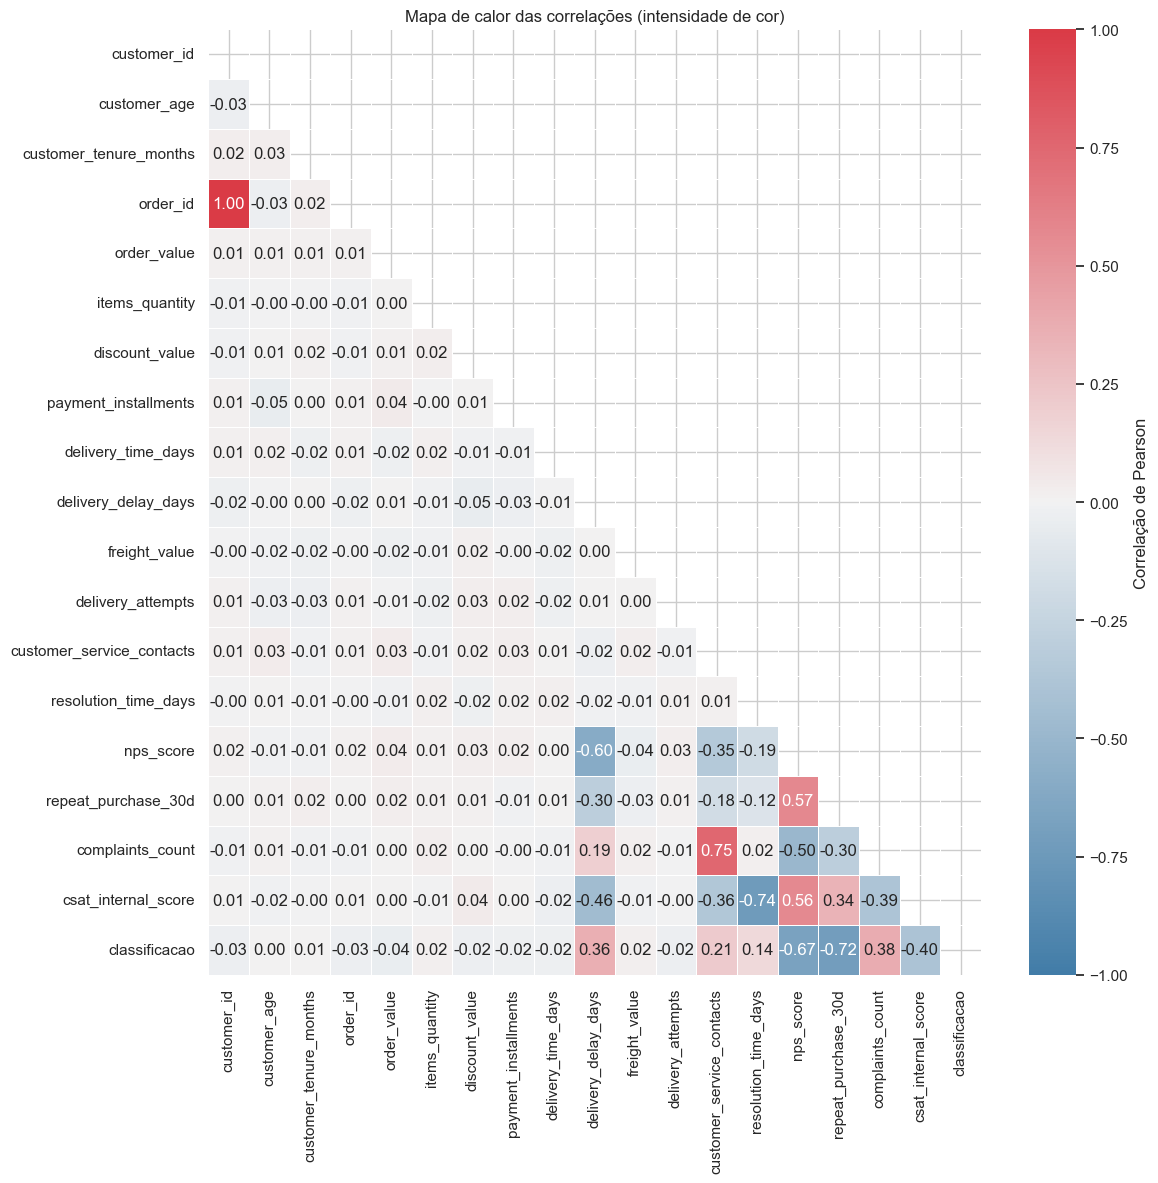

In [28]:
print_correlacao(df)

In [29]:
df.groupby('classificacao').agg(mean_nps=('nps_score', 'mean'), median_nps=('nps_score', 'median'))

,mean_nps,median_nps
classificacao,,
0,8.298977,8.1
1,3.651778,3.9


In [30]:
df.classificacao.value_counts()

classificacao
1    2109
0     391
Name: count, dtype: int64